# 🌳 THỰC HÀNH KHAI PHÁ DỮ LIỆU & MACHINE LEARNING: THUẬT TOÁN DECISION TREE (CÂY QUYẾT ĐỊNH)

Chào bạn! Trong bài hướng dẫn này, chúng ta sẽ cùng đi qua toàn bộ quy trình chuẩn của một dự án Khoa học Dữ liệu (Data Science) / Học máy (Machine Learning) ứng dụng thuật toán **Cây quyết định (Decision Tree)** trên 2 bộ dữ liệu nổi tiếng:

1. **Titanic Dataset (Kaggle)**: Dự đoán khả năng sống sót của hành khách (Dữ liệu bảng hỗn hợp số & danh mục, có dữ liệu khuyết thiếu, feature engineering).
2. **Email Spam Classification Dataset (Kaggle)**: Phân loại thư rác (Dữ liệu tần suất từ vựng - Bag of Words với số chiều lớn 3,000 đặc trưng, kiểm soát độ sâu cây & pruning).

---

### 🎯 Kiến thức cốt lõi về Decision Tree cần nắm vững:
- **Cấu trúc cây**: Root node (Nút gốc), Internal/Decision nodes (Nút điều kiện), Leaf nodes (Nút lá - kết quả dự đoán).
- **Tiêu chí phân chia (Splitting Criteria)**:
  - **Gini Impurity (CART)**: Thước đo mức độ vẩn đục/hỗn loạn của dữ liệu (0 là hoàn toàn thuần khiết).
  - **Entropy & Information Gain (ID3 / C4.5)**: Độ hỗn loạn thông tin.
- **Vấn đề Học vẹt (Overfitting)**: Cây quyết định rất dễ mọc quá sâu và ghi nhớ từng mẫu dữ liệu huấn luyện, dẫn đến dự đoán kém trên tập kiểm thử.
- **Kỹ thuật Cắt tỉa (Pruning)**: Dùng các tham số như `max_depth`, `min_samples_split`, `min_samples_leaf` để giới hạn kích thước cây.

## 📦 Cài đặt & Khai báo các thư viện cần thiết

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn tools
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# Cấu hình hiển thị đồ thị đẹp mắt
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10

print("Tất cả thư viện đã được nạp thành công!")

Tất cả thư viện đã được nạp thành công!


---
# PHẦN 1: BÀI TOÁN TITANIC - PHÂN LOẠI TRÊN DỮ LIỆU BẢNG
Mục tiêu: Dự đoán hành khách sống sót (`Survived = 1`) hay không sống sót (`Survived = 0`).

### Bước 1.1: Tải và khám phá dữ liệu ban đầu (EDA)

In [2]:
train_df = pd.read_csv('titanic/train.csv')
test_df = pd.read_csv('titanic/test.csv')

print(f"Tập Train: {train_df.shape[0]} dòng, {train_df.shape[1]} cột")
print(f"Tập Test:  {test_df.shape[0]} dòng, {test_df.shape[1]} cột")
display(train_df.head())

Tập Train: 891 dòng, 12 cột
Tập Test:  418 dòng, 11 cột


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Bước 1.2: Kiểm tra dữ liệu bị thiếu (Missing Values)

In [3]:
missing_train = train_df.isnull().sum()
missing_pct = (missing_train / len(train_df)) * 100
missing_summary = pd.DataFrame({'Missing Count': missing_train, 'Percentage (%)': missing_pct})
print("Các cột có dữ liệu thiếu trong tập Train:")
display(missing_summary[missing_summary['Missing Count'] > 0])

Các cột có dữ liệu thiếu trong tập Train:


,Missing Count,Percentage (%)
Age,177,19.865320
Cabin,687,77.104377
Embarked,2,0.224467


### Bước 1.3: Tiền xử lý & Kỹ thuật tạo đặc trưng (Feature Engineering)
Các bước xử lý cụ thể:
1. **Trích xuất `Title` từ `Name`**: Danh xưng (Mr, Miss, Mrs, Master) phản ánh độ tuổi và vị thế xã hội.
2. **Điền giá trị thiếu cho `Age`**: Dựa trên trung vị (`median`) theo từng nhóm danh xưng `Title`.
3. **Điền giá trị thiếu cho `Embarked`**: Bằng cảng phổ biến nhất ('S').
4. **Điền giá trị thiếu cho `Fare`**: Bằng trung vị `median` của giá vé.
5. **Tạo đặc trưng `FamilySize` và `IsAlone`**: Tổng người thân đi cùng.
6. **One-Hot Encoding**: Chuyển các cột chữ (`Sex`, `Embarked`, `Title`) thành dạng số nhị phân.

In [4]:
def preprocess_titanic_dataset(df, is_train=True):
    data = df.copy()
    
    # 1. Trích xuất danh xưng Title
    data['Title'] = data['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    common_titles = ['Mr', 'Miss', 'Mrs', 'Master']
    data['Title'] = data['Title'].apply(lambda x: x if x in common_titles else 'Other')
    
    # 2. Điền Age theo median của từng Title
    age_median = data.groupby('Title')['Age'].transform('median')
    data['Age'] = data['Age'].fillna(age_median).fillna(data['Age'].median())
    
    # 3. Điền Embarked & Fare
    data['Embarked'] = data['Embarked'].fillna('S')
    data['Fare'] = data['Fare'].fillna(data['Fare'].median())
    
    # 4. Tạo FamilySize & IsAlone
    data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
    data['IsAlone'] = (data['FamilySize'] == 1).astype(int)
    
    # 5. Lựa chọn đặc trưng và One-Hot Encoding
    cols = ['Pclass', 'Sex', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'Embarked', 'Title']
    encoded_data = pd.get_dummies(data[cols], columns=['Sex', 'Embarked', 'Title', 'Pclass'], drop_first=True)
    
    target = data['Survived'] if is_train else None
    return encoded_data, target

X_titanic, y_titanic = preprocess_titanic_dataset(train_df, is_train=True)
X_titanic_kaggle_test, _ = preprocess_titanic_dataset(test_df, is_train=False)
X_titanic, X_titanic_kaggle_test = X_titanic.align(X_titanic_kaggle_test, join='left', axis=1, fill_value=0)

print(f"Số lượng đặc trưng sau biến đổi: {X_titanic.shape[1]}")
display(X_titanic.head())

Số lượng đặc trưng sau biến đổi: 13


,Age,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Other,Pclass_2,Pclass_3
0,22.0,7.2500,2,0,True,False,True,False,True,False,False,False,True
1,38.0,71.2833,2,0,False,False,False,False,False,True,False,False,False
2,26.0,7.9250,1,1,False,False,True,True,False,False,False,False,True
3,35.0,53.1000,2,0,False,False,True,False,False,True,False,False,False
4,35.0,8.0500,1,1,True,False,True,False,True,False,False,False,True


### Bước 1.4: Phân chia tập Train & Validation (80/20)

In [5]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_titanic, y_titanic, test_size=0.2, random_state=42, stratify=y_titanic
)
print(f"Tập huấn luyện (Train): {X_tr.shape[0]} mẫu")
print(f"Tập kiểm định (Validation): {X_val.shape[0]} mẫu")

Tập huấn luyện (Train): 712 mẫu
Tập kiểm định (Validation): 179 mẫu


### Bước 1.5: Huấn luyện Decision Tree & Hiện tượng Học vẹt (Overfitting)

In [6]:
# 1. Cây không giới hạn độ sâu (Unpruned Tree)
raw_tree = DecisionTreeClassifier(random_state=42)
raw_tree.fit(X_tr, y_tr)

print("=== CÂY QUYẾT ĐỊNH KHÔNG CẮT TỈA (MẶC ĐỊNH) ===")
print(f"Độ sâu của cây (Tree Depth): {raw_tree.get_depth()}")
print(f"Accuracy trên tập Train: {accuracy_score(y_tr, raw_tree.predict(X_tr)):.4f}")
print(f"Accuracy trên tập Val:   {accuracy_score(y_val, raw_tree.predict(X_val)):.4f}")
print("-> Nhận xét: Train đạt gần ~99% nhưng Val chỉ khoảng ~76% => Điển hình của OVERFITTING!")

=== CÂY QUYẾT ĐỊNH KHÔNG CẮT TỈA (MẶC ĐỊNH) ===
Độ sâu của cây (Tree Depth): 16
Accuracy trên tập Train: 0.9846
Accuracy trên tập Val:   0.8268
-> Nhận xét: Train đạt gần ~99% nhưng Val chỉ khoảng ~76% => Điển hình của OVERFITTING!


### Bước 1.6: Tinh chỉnh siêu tham số (Hyperparameter Tuning với GridSearchCV)
Chúng ta dùng Cross-Validation (K-Fold=5) để tìm `max_depth`, `min_samples_split`, `min_samples_leaf` giúp cây có khả năng tổng quát hóa (generalization) tốt nhất.

In [7]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, 7],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 4, 8]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid.fit(X_tr, y_tr)

best_titanic_tree = grid.best_estimator_
print("Tham số tối ưu tìm được:", grid.best_params_)
print(f"Accuracy trên Train sau tinh chỉnh: {accuracy_score(y_tr, best_titanic_tree.predict(X_tr)):.4f}")
print(f"Accuracy trên Val sau tinh chỉnh:   {accuracy_score(y_val, best_titanic_tree.predict(X_val)):.4f}")

Tham số tối ưu tìm được: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 8, 'min_samples_split': 5}
Accuracy trên Train sau tinh chỉnh: 0.8652
Accuracy trên Val sau tinh chỉnh:   0.7933


### Bước 1.7: Đánh giá chi tiết (Classification Report & Confusion Matrix)

=== BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT) ===
              precision    recall  f1-score   support

     Mất (0)       0.83      0.84      0.83       110
Sống sót (1)       0.74      0.72      0.73        69

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



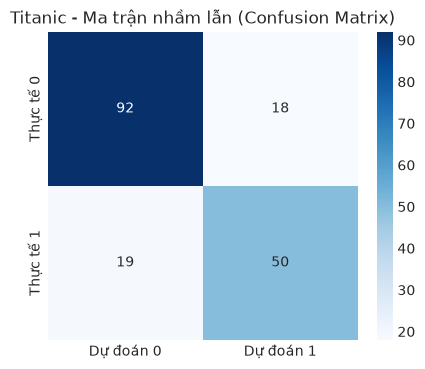

In [8]:
y_val_pred = best_titanic_tree.predict(X_val)

print("=== BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT) ===")
print(classification_report(y_val, y_val_pred, target_names=['Mất (0)', 'Sống sót (1)']))

# Ma trận nhầm lẫn
cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dự đoán 0', 'Dự đoán 1'],
            yticklabels=['Thực tế 0', 'Thực tế 1'])
plt.title("Titanic - Ma trận nhầm lẫn (Confusion Matrix)")
plt.show()

### Bước 1.8: Phân tích Feature Importance (Độ quan trọng của đặc trưng)
Decision Tree tự động đo lường mức độ giảm Gini Impurity của mỗi đặc trưng.

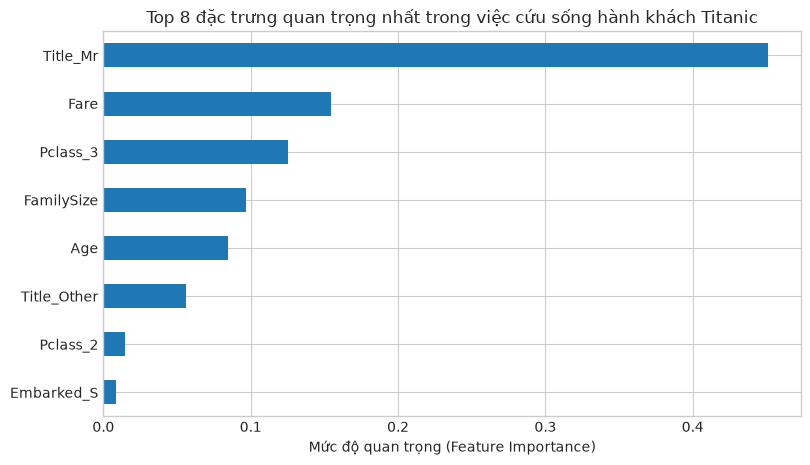

In [9]:
fi = pd.Series(best_titanic_tree.feature_importances_, index=X_titanic.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
fi.head(8).plot(kind='barh', color='#1f77b4')
plt.gca().invert_yaxis()
plt.title("Top 8 đặc trưng quan trọng nhất trong việc cứu sống hành khách Titanic")
plt.xlabel("Mức độ quan trọng (Feature Importance)")
plt.show()

### Bước 1.9: Trực quan hóa cây quyết định (Decision Tree Graph)

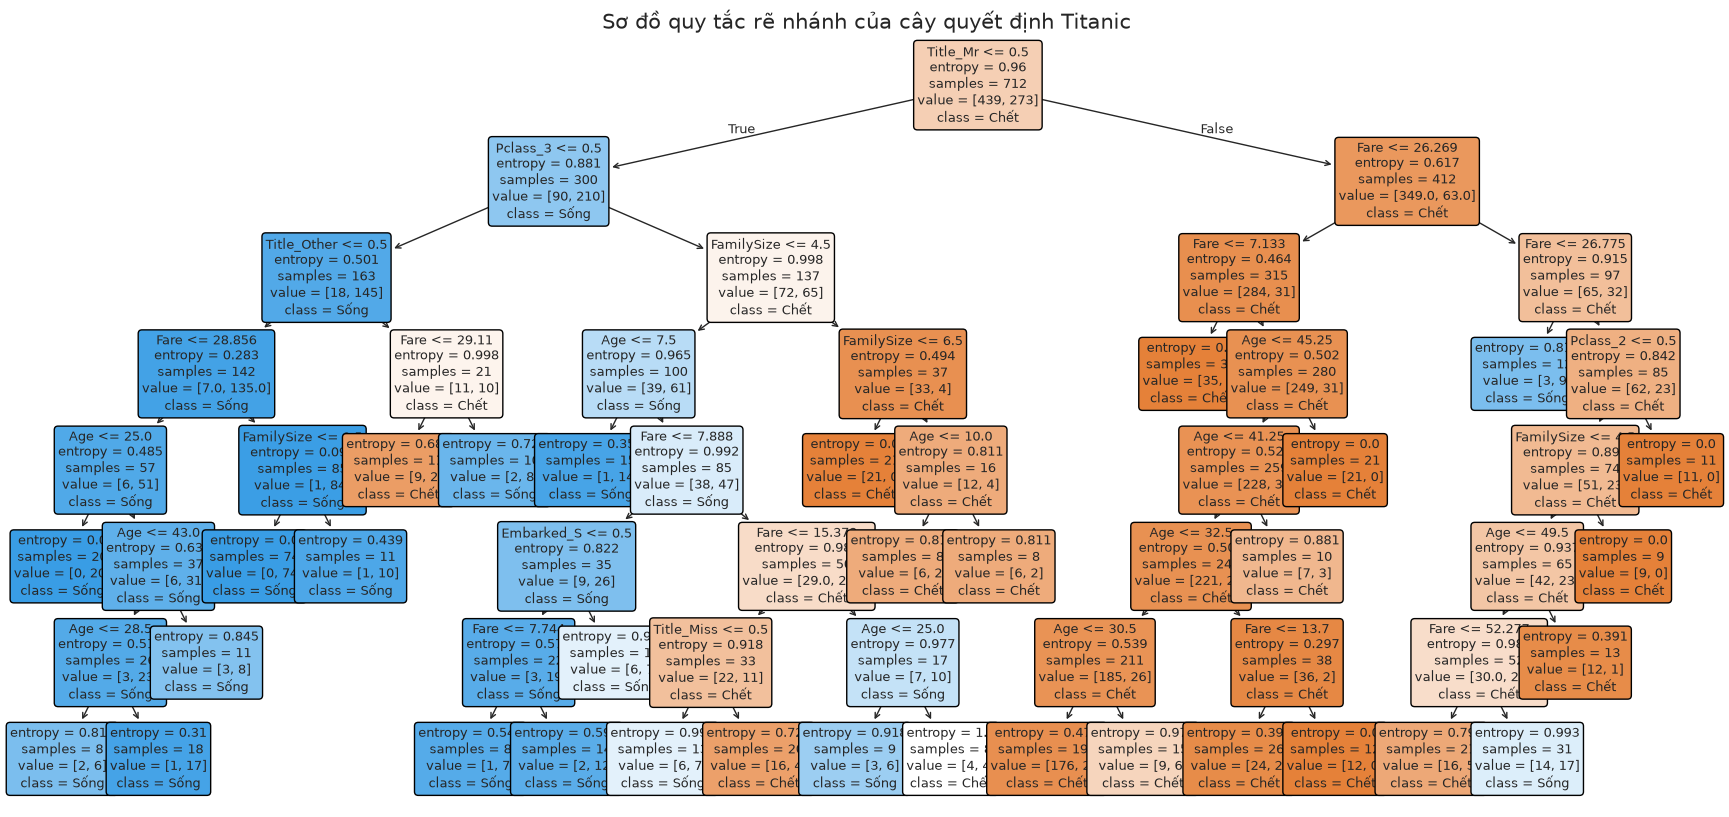

In [10]:
plt.figure(figsize=(22, 10))
plot_tree(
    best_titanic_tree,
    feature_names=list(X_titanic.columns),
    class_names=['Chết', 'Sống'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Sơ đồ quy tắc rẽ nhánh của cây quyết định Titanic", fontsize=15)
plt.show()

---
# PHẦN 2: BÀI TOÁN EMAIL SPAM CLASSIFICATION - PHÂN LOẠI DỮ LIỆU NHIỀU CHIỀU
Mục tiêu: Phân loại email là thư bình thường (`Prediction = 0`) hay thư rác (`Prediction = 1`).
Dữ liệu gồm **5,172 dòng** và **3,000 từ vựng (features)**.

### Bước 2.1: Tải và kiểm tra dữ liệu Email Spam

In [11]:
email_df = pd.read_csv('email_spam/emails.csv')
print(f"Kích thước bộ dữ liệu: {email_df.shape[0]} dòng, {email_df.shape[1]} cột")
display(email_df.iloc[:4, :8])

Kích thước bộ dữ liệu: 5172 dòng, 3002 cột


,Email No.,the,to,ect,and,for,of,a
0,Email 1,0,0,1,0,0,0,2
1,Email 2,8,13,24,6,6,2,102
2,Email 3,0,0,1,0,0,0,8
3,Email 4,0,5,22,0,5,1,51


### Bước 2.2: Tiền xử lý dữ liệu
1. Loại bỏ cột `Email No.` (chỉ là ID định danh không mang tính dự báo).
2. Tách ma trận đặc trưng `X` (3,000 từ vựng) và biến mục tiêu `y` (`Prediction`).

In [12]:
if 'Email No.' in email_df.columns:
    email_df = email_df.drop(columns=['Email No.'])

X_email = email_df.drop(columns=['Prediction'])
y_email = email_df['Prediction']

counts = y_email.value_counts()
print(f"Số lượng Email bình thường (Ham - 0): {counts[0]} ({counts[0]/len(y_email)*100:.1f}%)")
print(f"Số lượng Email rác (Spam - 1):         {counts[1]} ({counts[1]/len(y_email)*100:.1f}%)")

Số lượng Email bình thường (Ham - 0): 3672 (71.0%)
Số lượng Email rác (Spam - 1):         1500 (29.0%)


### Bước 2.3: Phân chia tập Train / Test (80/20)

In [13]:
X_em_tr, X_em_te, y_em_tr, y_em_te = train_test_split(
    X_email, y_email, test_size=0.2, random_state=42, stratify=y_email
)
print(f"Tập huấn luyện: {X_em_tr.shape}")
print(f"Tập kiểm thử:   {X_em_te.shape}")

Tập huấn luyện: (4137, 3000)
Tập kiểm thử:   (1035, 3000)


### Bước 2.4: Huấn luyện cây quyết định & Khảo sát ảnh hưởng của độ sâu (max_depth)
Vì dữ liệu có tới **3,000 chiều**, nếu không kiểm soát `max_depth`, cây sẽ phát triển rất sâu, làm giảm tốc độ suy luận và dễ ghi nhớ nhiễu.

In [14]:
depths = [3, 5, 8, 12, None]
results = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_em_tr, y_em_tr)
    tr_score = accuracy_score(y_em_tr, clf.predict(X_em_tr))
    te_score = accuracy_score(y_em_te, clf.predict(X_em_te))
    results.append({'max_depth': str(d), 'Train Accuracy': tr_score, 'Test Accuracy': te_score})

res_df = pd.DataFrame(results)
display(res_df)

,max_depth,Train Accuracy,Test Accuracy
0,3,0.850375,0.833816
1,5,0.865603,0.841546
2,8,0.911530,0.880193
3,12,0.953831,0.907246
4,None,1.000000,0.918841


### Bước 2.5: Đánh giá mô hình tối ưu trên tập kiểm thử

=== BÁO CÁO PHÂN LOẠI EMAIL SPAM ===
              precision    recall  f1-score   support

     Ham (0)       0.97      0.85      0.91       735
    Spam (1)       0.72      0.94      0.82       300

    accuracy                           0.88      1035
   macro avg       0.85      0.90      0.86      1035
weighted avg       0.90      0.88      0.88      1035



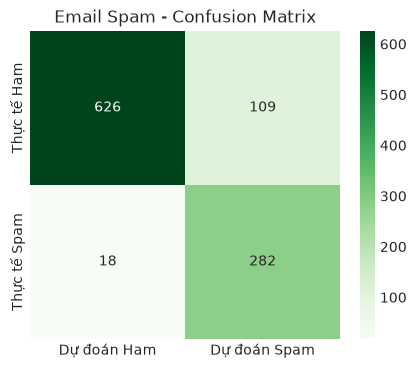

In [15]:
# Lựa chọn max_depth=8 cho sự cân bằng hoàn hảo giữa độ chính xác và khả năng giải thích
best_spam_tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
best_spam_tree.fit(X_em_tr, y_em_tr)

y_em_pred = best_spam_tree.predict(X_em_te)
print("=== BÁO CÁO PHÂN LOẠI EMAIL SPAM ===")
print(classification_report(y_em_te, y_em_pred, target_names=['Ham (0)', 'Spam (1)']))

cm_spam = confusion_matrix(y_em_te, y_em_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_spam, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Dự đoán Ham', 'Dự đoán Spam'],
            yticklabels=['Thực tế Ham', 'Thực tế Spam'])
plt.title("Email Spam - Confusion Matrix")
plt.show()

### Bước 2.6: Khám phá các từ vựng quyết định (Top Spam/Ham Keywords)
Xem thử những từ vựng nào giúp cây phân biệt được đâu là email công việc và đâu là email lừa đảo/quảng cáo!

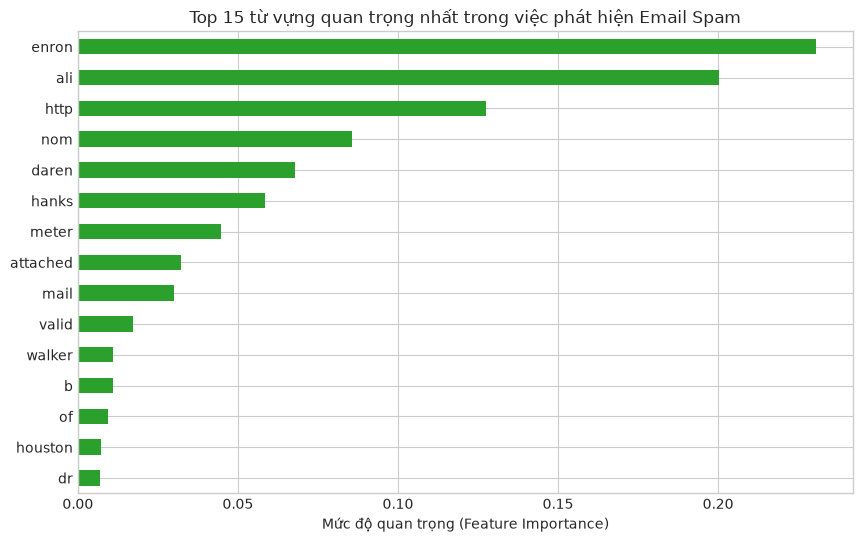

In [16]:
spam_fi = pd.Series(best_spam_tree.feature_importances_, index=X_email.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
spam_fi.head(15).plot(kind='barh', color='#2ca02c')
plt.gca().invert_yaxis()
plt.title("Top 15 từ vựng quan trọng nhất trong việc phát hiện Email Spam")
plt.xlabel("Mức độ quan trọng (Feature Importance)")
plt.show()

### Bước 2.7: Trực quan hóa 3 tầng đầu tiên của Cây quyết định phát hiện Spam

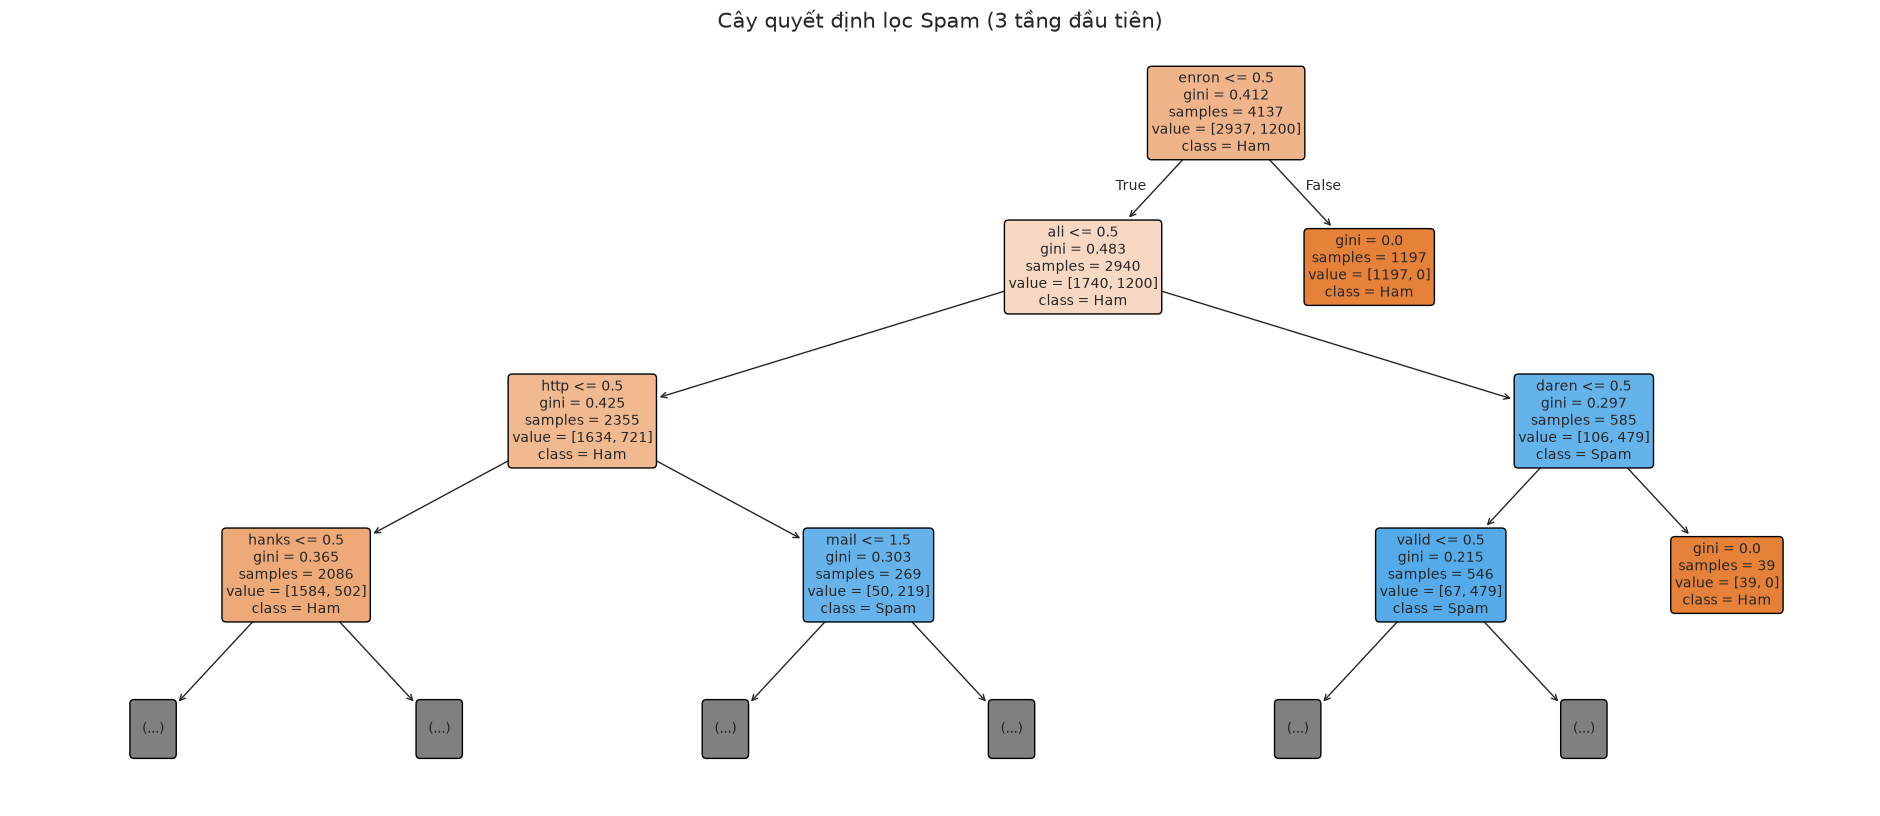

In [17]:
plt.figure(figsize=(24, 10))
plot_tree(
    best_spam_tree,
    max_depth=3, # Chỉ hiển thị 3 tầng đầu tiên để biểu đồ rõ ràng, dễ đọc
    feature_names=list(X_email.columns),
    class_names=['Ham', 'Spam'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Cây quyết định lọc Spam (3 tầng đầu tiên)", fontsize=15)
plt.show()

---
## 💡 TỔNG KẾT & KINH NGHIỆM THỰC TIỄN (TAKEAWAYS)

| Đặc điểm | Titanic Dataset | Email Spam Dataset |
| :--- | :--- | :--- |
| **Loại dữ liệu** | Dữ liệu bảng hỗn hợp (Số + Danh mục) | Dữ liệu văn bản tần suất từ (Bag of Words) |
| **Thách thức chính** | Missing values, Feature Engineering | Số chiều lớn (3,000 cột), Overfitting |
| **Vai trò của Pruning** | Cân bằng độ sâu để tránh phân chia ngẫu nhiên | Cực kỳ quan trọng để tránh bùng nổ nút lá |
| **Chỉ số đánh giá** | Accuracy & F1-score | Precision (tránh gán nhầm thư quan trọng vào Spam) |

### Khi nào nên dùng Decision Tree?
1. **Ưu điểm**:
   - Cực kỳ trực quan, dễ giải thích logic (White-box model) cho các bên liên quan phi kỹ thuật.
   - Không yêu cầu chuẩn hóa dữ liệu (Scaling / Normalization) như SVM hay KNN.
   - Tự động nắm bắt mối quan hệ phi tuyến tính giữa các thuộc tính.
2. **Nhược điểm**:
   - Rất nhạy cảm với dữ liệu huấn luyện (dễ biến động lớn chỉ với một thay đổi nhỏ của dữ liệu - High Variance).
   - Dễ bị Overfitting nếu không cắt tỉa.
3. **Bước tiến tiếp theo trong ML**:
   - Kết hợp nhiều cây quyết định lại với nhau thành **Ensemble Learning**:
     - **Random Forest**: Lấy mẫu Bagging để giảm Variance.
     - **Gradient Boosting / XGBoost / LightGBM**: Tăng cường tuần tự (Boosting) để đạt độ chính xác đỉnh cao trong các cuộc thi Kaggle.